In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs

# Introduction

## Cluster plots

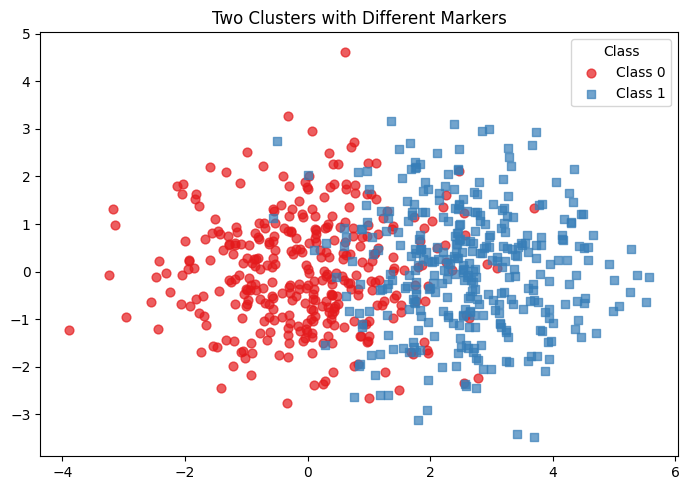

In [98]:
palette = sns.color_palette('Set1', n_colors=5)
def plot_clusters(n_samples=1000, centers=3, cluster_std=1.2, markers={0: 'o', 1: 's'}, colors=None, title='Clusters'):
    # Generate data
    X, y = make_blobs(
        n_samples=n_samples, 
        centers=centers,
        cluster_std=cluster_std, 
        random_state=42
    )
    df = pd.DataFrame(X, columns=['feature1', 'feature2'])
    df['label'] = y

    plt.figure(figsize=(7, 5))
    markers = markers
    # Use provided colors or default palette
    if colors is None:
        palette = sns.color_palette('Set1', n_colors=len(np.unique(y)))
        colors = {label: palette[label] for label in np.unique(y)}
    else:
        # If colors is a list, convert to dict
        if isinstance(colors, list):
            colors = {label: colors[label] for label in np.unique(y)}
    for label in np.unique(y):
        subset = df[df['label'] == label]
        plt.scatter(
            subset['feature1'], subset['feature2'],
            marker=markers.get(label, 'o'),
            color=colors.get(label, 'gray'),
            alpha=0.7, s=40, label=f'Class {label}'
        )
    plt.xlabel('')
    plt.ylabel('')
    plt.title(title)
    plt.legend(title='Class')
    plt.tight_layout()
    plt.show()

plot_clusters(
    n_samples=700,
    centers=[(0,0), (2.5,0)],
    colors=[palette[0], palette[1]],  # Pass the palette directly
    markers={0: 'o', 1: 's'},
    title='Two Clusters with Different Markers'
)

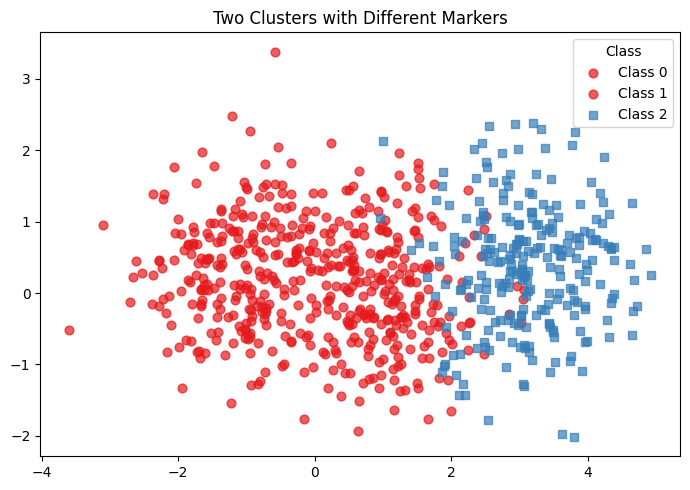

In [122]:
plot_clusters(
    n_samples=750,
    centers=[(-1,0.3), (1,0), (3,0.3)],
    cluster_std=0.8,
    colors=[palette[0], palette[0], palette[1]],  # Pass the palette directly
    markers={0: 'o', 1: 'o', 2: 's'},
    title='Two Clusters with Different Markers'
)

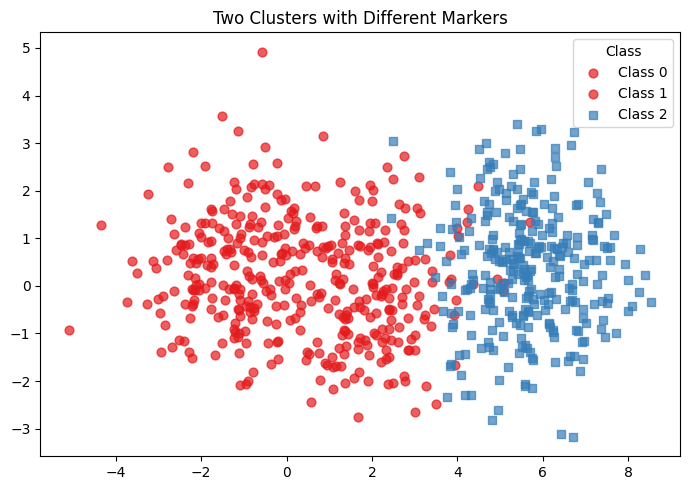

In [183]:
plot_clusters(
    n_samples=[200,200,300],
    centers=[(-1.2,0.3), (2,0), (5.5,0.3)],
    cluster_std=1.2,
    colors=[palette[0], palette[0], palette[1]],  # Pass the palette directly
    markers={0: 'o', 1: 'o', 2: 's'},
    title='Two Clusters with Different Markers'
)

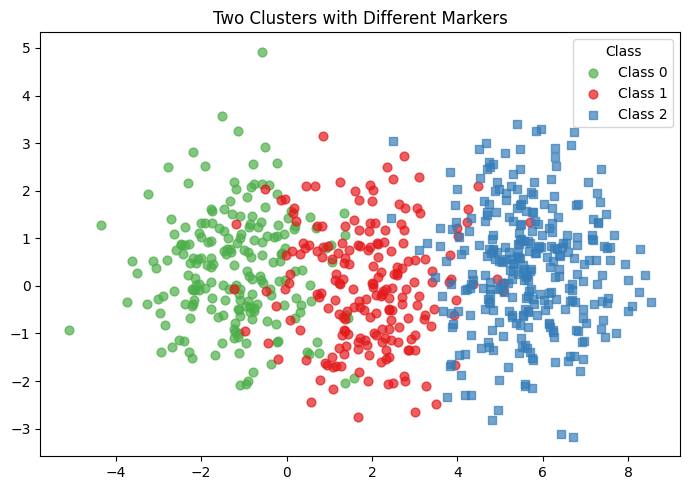

In [184]:
plot_clusters(
    n_samples=[200,200,300],
    centers=[(-1.2,0.3), (2,0), (5.5,0.3)],
    cluster_std=1.2,
    colors=[palette[2], palette[0], palette[1]],  # Pass the palette directly
    markers={0: 'o', 1: 'o', 2: 's'},
    title='Two Clusters with Different Markers'
)

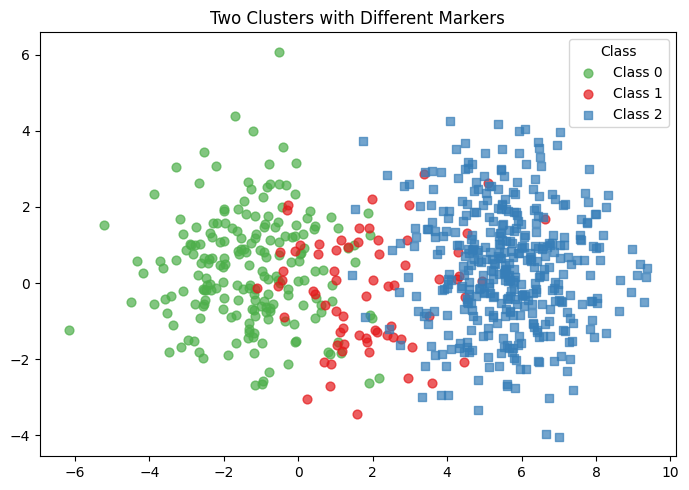

In [185]:
plot_clusters(
    n_samples=[200,70,400],
    centers=[(-1.3,0.3), (2,0), (5.5,0.3)],
    cluster_std=1.5,
    colors=[palette[2], palette[0], palette[1]],  # Pass the palette directly
    markers={0: 'o', 1: 'o', 2: 's'},
    title='Two Clusters with Different Markers'
)

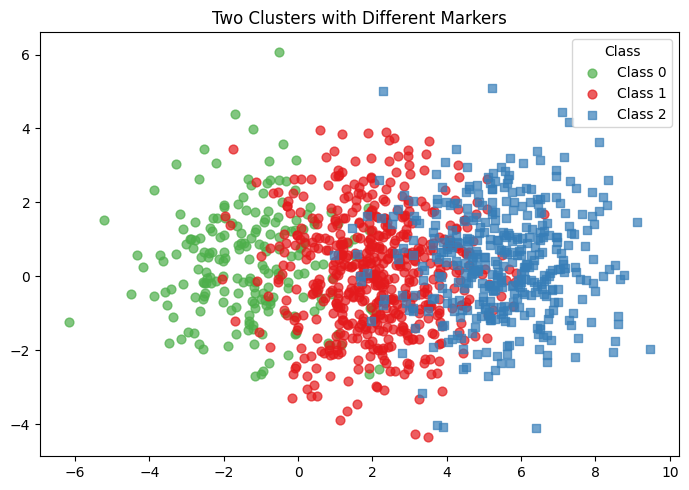

In [186]:
plot_clusters(
    n_samples=[200,550,400],
    centers=[(-1.3,0.3), (2,0), (5.5,0.3)],
    cluster_std=1.5,
    colors=[palette[2], palette[0], palette[1]],  # Pass the palette directly
    markers={0: 'o', 1: 'o', 2: 's'},
    title='Two Clusters with Different Markers'
)

## Score density plots

In [187]:
def MoSS(n, alpha, m):
    p_score = np.random.uniform(size=int(n * alpha)) ** m
    n_score = 1 - (np.random.uniform(size=int(round(n * (1 - alpha), 0))) ** m)
    scores = np.column_stack((np.concatenate((p_score, n_score)), np.concatenate((np.ones(len(p_score)), np.full(len(n_score), 0)))))
    # pdb.set_trace()
    return scores

MoSS(1000, 0.5, 0.3)

array([[0.4266912 , 1.        ],
       [0.70684497, 1.        ],
       [0.99946083, 1.        ],
       ...,
       [0.12467069, 0.        ],
       [0.17518832, 0.        ],
       [0.38588816, 0.        ]], shape=(1000, 2))

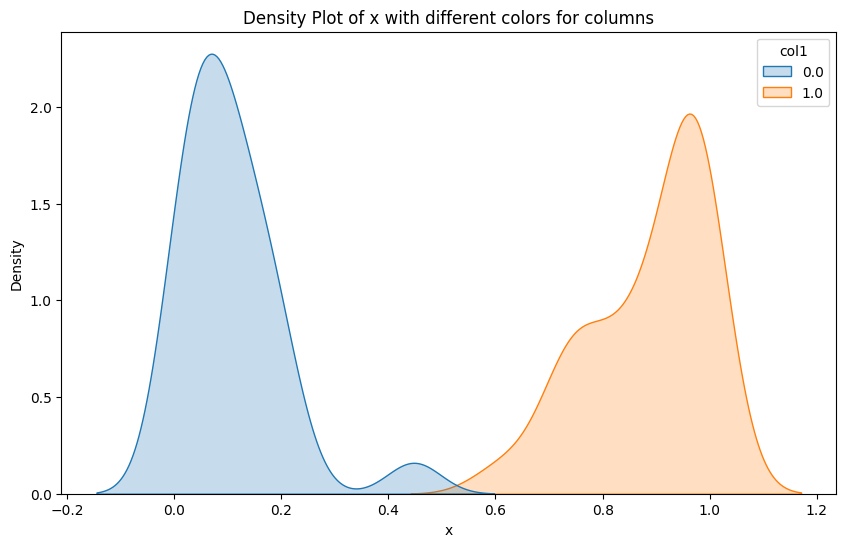

In [308]:
x=MoSS(50, 0.5, 0.1)
x = pd.DataFrame(x)
x.columns = ['x', 'col1']

def plot_density(x):
    # Create the density plot
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=x, x='x', hue='col1', fill=True)

    plt.title('Density Plot of x with different colors for columns')
    plt.xlabel('x')
    plt.ylabel('Density')
    plt.show()

plot_density(x)


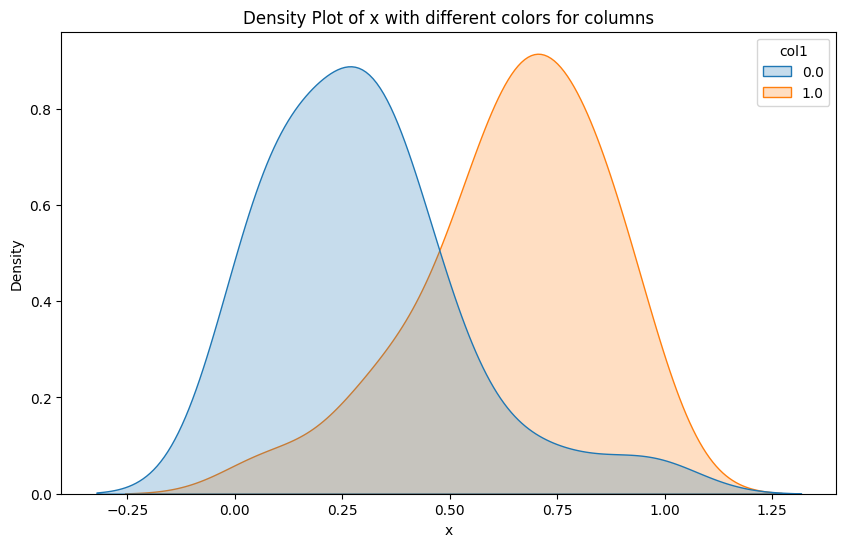

In [221]:
x=MoSS(50, 0.5, 0.4)
x = pd.DataFrame(x)
x.columns = ['x', 'col1']

plot_density(x)

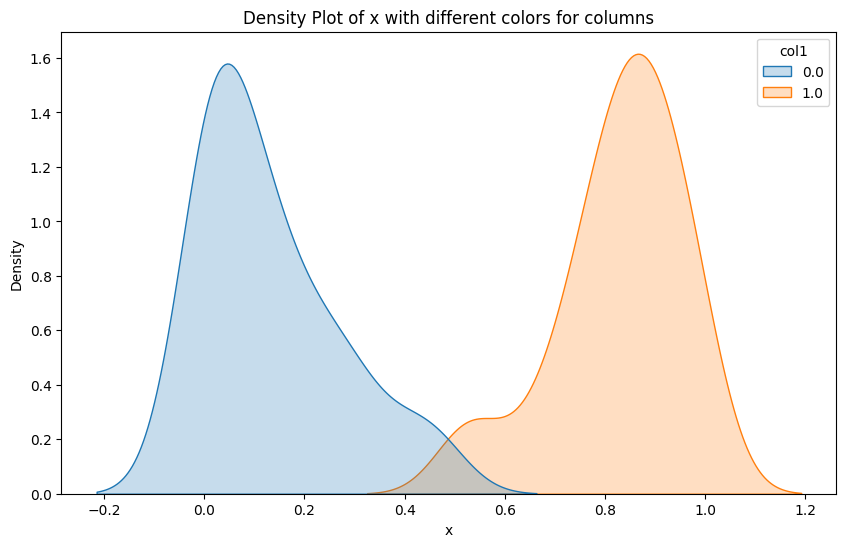

In [316]:
x=MoSS(50, 0.5, 0.2)
x = pd.DataFrame(x)
x.columns = ['x', 'col1']

def plot_density(x):
    # Create the density plot
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=x, x='x', hue='col1', fill=True)

    plt.title('Density Plot of x with different colors for columns')
    plt.xlabel('x')
    plt.ylabel('Density')
    plt.show()

plot_density(x)


# Results

In [2]:
results_path = '/results_paper/'

## Synthetic

In [ ]:
df_syn = pd.read_csv('results_syn_10_rep.csv')
df_syn

FileNotFoundError: [Errno 2] No such file or directory: '/results_paper/results_syn_10_rep.csv'

## Real